# Cжатие изображений с помощью SVD-разложения


Одним из самых популярных способов применения SVD-разложения является сжатие данных. Как уже упоминалось, SVD устроен таким образом, что если мы удаляем компоненты, связанные с наименьшими сингулярными значениями, мы теряем лишь незначительную часть важной информации, а часто — только шум, который практически не влияет на качество данных. Благодаря этому можно эффективно сжимать различные объекты без существенной потери качества их представления. Наиболее наглядным примером такого подхода является сжатие изображений.


Естественно, само по себе изображение не является математическим объектом. После цифровизации его можно представить в виде набора пикселей. Обычно это несколько матриц: например, в случае цветовой модели RGB (Red, Green, Blue) изображение кодируется тремя матрицами, каждая из которых отвечает за свой цвет.

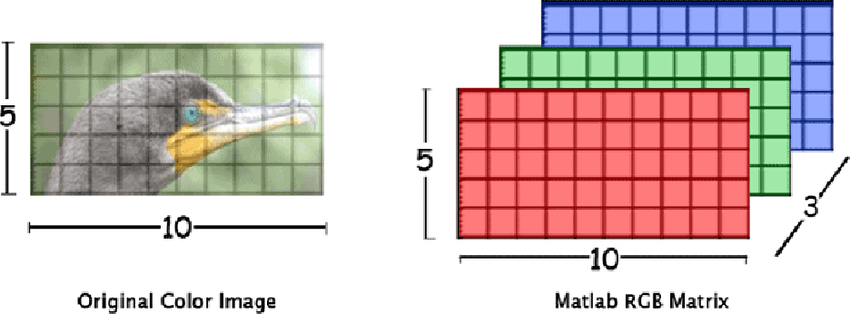

Для простоты рассмотрим случай, когда используется только одна матрица — это соответствует чёрно-белому изображению. В таком изображении единственный параметр, который нужно хранить, — это интенсивность серого цвета. Таким образом, чёрно-белое изображение можно представить как матрицу серых оттенков, к которой затем можно применить SVD-преобразование.

In [ ]:
"""
Технические функции, которые упростят нам процесс работы с google-colab
"""
from IPython.display import display
from google.colab import output

"""
Заранее необходимые модули
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
# Загрузим изображение розы с Wikipedia
! wget "https://upload.wikimedia.org/wikipedia/commons/d/db/Rosa_Peer_Gynt_1.jpg"
output.clear()

### Что именно делает SVD с изображением?

**Шаг 1 — Матрица яркостей.**  
Изображение $1503 \times 1600$ → матрица $A$ размером $1503 \times 1600$, где каждый элемент $A_{ij} \in [0, 255]$ — яркость пикселя (0 = чёрный, 255 = белый).

**Шаг 2 — SVD-разложение.**  
$$A = U \cdot \Sigma \cdot V^T$$

- $U$ $(1503 \times 1503)$ — паттерны **по строкам** (вертикальные структуры изображения)
- $\Sigma$ — диагональная матрица **сингулярных значений** $\sigma_1 \geq \sigma_2 \geq \ldots \geq 0$
- $V^T$ $(1600 \times 1600)$ — паттерны **по столбцам** (горизонтальные структуры)

**Шаг 3 — Интуиция.**  
SVD представляет изображение как сумму *ранговых слоёв*:
$$A = \sigma_1 \cdot u_1 v_1^T + \sigma_2 \cdot u_2 v_2^T + \ldots + \sigma_r \cdot u_r v_r^T$$

Каждый слой $\sigma_i \cdot u_i v_i^T$ — это "набросок" изображения: $u_i$ задаёт вертикальный паттерн, $v_i$ — горизонтальный.  
$\sigma_i$ — **важность** слоя: чем больше, тем больше дисперсии (информации) он несёт.

**Шаг 4 — Сжатие.**  
Оставляем только первые $k$ слоёв:
$$A_k = \sum_{i=1}^{k} \sigma_i \cdot u_i v_i^T$$

Вместо $1503 \times 1600 = 2\,404\,800$ чисел храним $k \times (1503 + 1 + 1600)$ — при $k=100$ это $\approx 310\,000$ чисел, сжатие в **8 раз**.

> **Уточнение к твоему вопросу:** SVD не ищет «корреляцию чёрного и белого» — он ищет **направления максимальной дисперсии** в матрице яркостей. Первый слой захватывает самый выраженный паттерн (например, общий фон и крупные формы), последующие — всё более мелкие детали, последние — шум.

Так как ИСХОДНАЯ картинка содержит три канала: красный (R), зеленый (G), синий (B), сконвертируем ее в черно-белое изображение, чтобы получить матрицу.

Для этого воспользуемся функцией .convert() довольно известной библиотеки Python Image Library (PIL), предназначенной специально для работы с графическими данными в Python.

In [ ]:
from PIL import Image

get_ipython().__class__.__name__ = "ZMQInteractiveShell"

filename = "Rosa_Peer_Gynt_1.jpg"
img = Image.open(filename).convert("L")
print(img.size)

(1600, 1503)


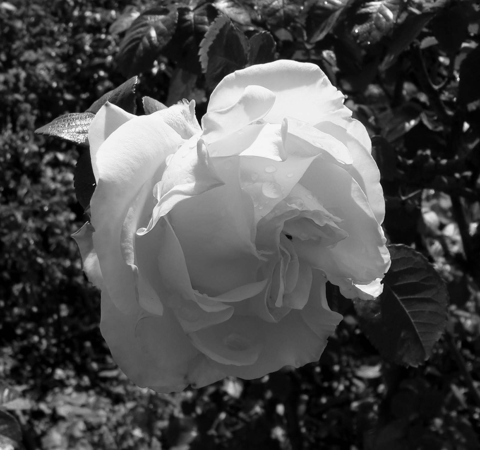

In [ ]:
scale = 0.3
display(img.resize((int(img.width * scale), int(img.height * scale))))

In [ ]:
img_array = np.asarray(img)
img_array.shape

(1503, 1600)

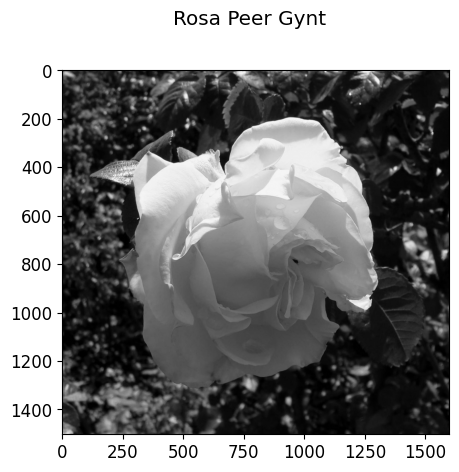

In [ ]:
plt.rcParams["font.size"] = 12
fg_color = "black"
bg_color = "white"

fig = plt.figure(figsize=(5, 5))
fig.set_facecolor(bg_color)
im = plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)
fig.suptitle("Rosa Peer Gynt", color=fg_color)
im.axes.tick_params(color=fg_color, labelcolor=fg_color)

`plt.rcParams["font.size"] = 12` — устанавливает размер шрифта текста на графике.

`fg_color = "black" и bg_color = "white"` — задают цвет переднего плана (текста, осей) и фона фигуры.

`fig = plt.figure(figsize=(5, 5))` — создаёт фигуру размером 5×5 дюймов.

`fig.set_facecolor(bg_color)` — задаёт цвет фона фигуры.

`im = plt.imshow(img_array, cmap="gray", vmin=0, vmax=255)` — отображает изображение в оттенках серого с диапазоном пикселей от 0 до 255.

`fig.suptitle("Rosa Peer Gynt", color=fg_color)` — добавляет заголовок к фигуре с указанным цветом текста.

`im.axes.tick_params(color=fg_color, labelcolor=fg_color)` — задаёт цвет осей и подписей делений.

Итак, мы разобрались с тем, как представлено изображение в виде массива. На текущий момент изображение хранится в переменной `img_array`. Самое время сделать SVD-преобразование.

In [ ]:
U, D, V = np.linalg.svd(img_array)

In [ ]:
def svd_transformation(A, n_comps):

    U, D, V = np.linalg.svd(A)

    # По определению svd-преобразования, обрежем соответствующие матрицы
    U_cuted = U[:, :n_comps]
    D_cuted = np.diag(D[:n_comps])
    V_cuted = V[:n_comps, :]

    print(f'Количество компонент: {n_comps}, Количество пикселей: {U_cuted.shape[0]*U_cuted.shape[1] + D_cuted.shape[0] + V_cuted.shape[0]*V_cuted.shape[1]}')

    # Затем выполним их матричное умножение
    transformed = U_cuted @ D_cuted @ V_cuted
    return transformed

Теперь попробуем получить изображения при помощи сжатия размерности исходной матрицы до 50, 100, 150 и 200 компонент.

Количество компонент: 50, Количество пикселей: 155200

Количество компонент: 100, Количество пикселей: 310400

Количество компонент: 150, Количество пикселей: 465600

Количество компонент: 200, Количество пикселей: 620800



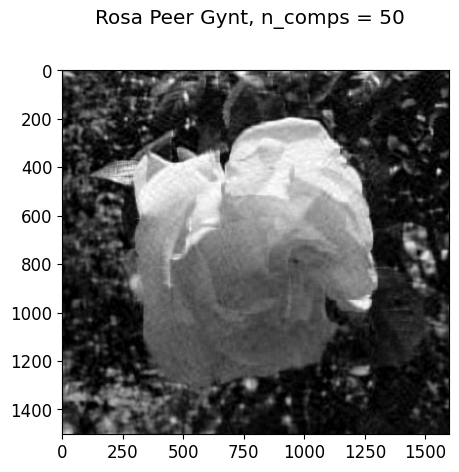

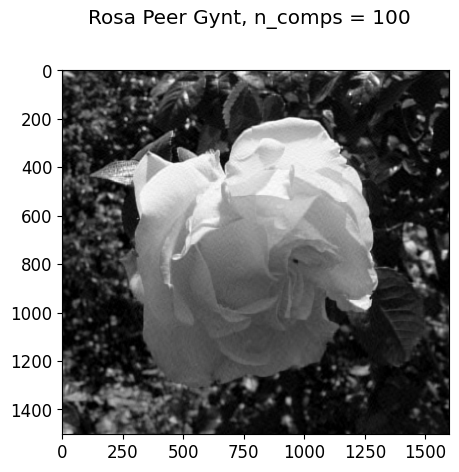

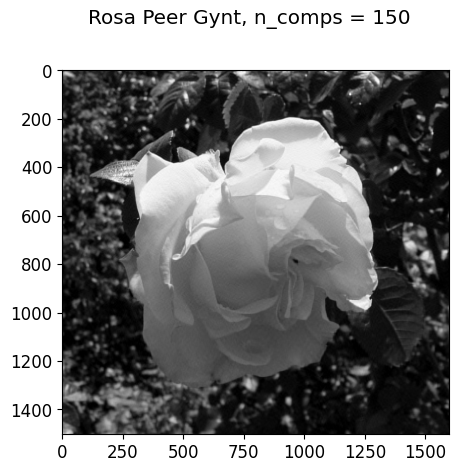

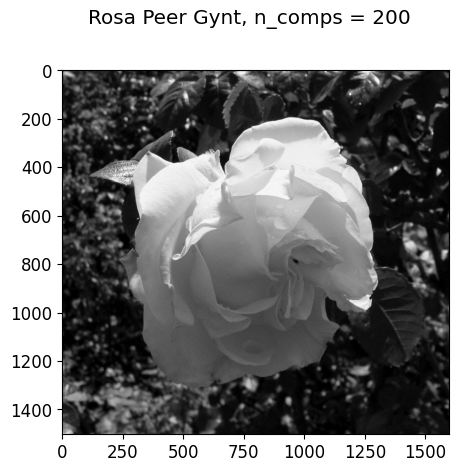

In [ ]:
for n_comps in [50, 100, 150, 200]:
    # SVD-преобразование
    reconst_img = svd_transformation(img_array, n_comps)

    # Отрисовка результата
    print()
    fig = plt.figure(figsize=(5, 5))
    im = plt.imshow(reconst_img, cmap="gray", vmin=0, vmax=255)
    fig.suptitle(f"Rosa Peer Gynt, n_comps = {n_comps}", color=fg_color)
    fig.set_facecolor(bg_color)
    im.axes.tick_params(color=fg_color, labelcolor=fg_color)

# Нахождение главных компонент, демонстрация PCA

### Интуиция: что такое PCA и зачем он нужен

**Связь SVD и PCA.**  
SVD — это математический инструмент: он переводит матрицу в базис, где она делает только одно простое действие — растягивает или сжимает вдоль осей. Никаких поворотов, никакого смешивания направлений.  
Сразу видно: вот это направление матрица тянет сильно (большое $\sigma$) — здесь данные разбросаны больше всего. Вот это почти не трогает (маленькое $\sigma$) — здесь почти нет информации.  
PCA использует именно это: **наибольшие изменения = наибольший разброс = главные компоненты.**

**Что происходит при `PCA(n_components=k)`:**
1. Данные центрируются (вычитается среднее)
2. Строится ковариационная матрица — она показывает, какие признаки меняются вместе
3. SVD находит направления максимальной дисперсии — это и есть **главные компоненты** (eigenbasis)
4. Данные проецируются на первые $k$ таких направлений

Каждая главная компонента — это **линейная комбинация исходных признаков**, выровненная вдоль наибольшего разброса.

**Два способа использовать PCA:**

| Цель | Что делаем | Результат |
|---|---|---|
| Диагностика | Смотрим `explained_variance_` | Видим, какие признаки мультиколлинеарны (дают одну компоненту) |
| Обработка данных | Заменяем признаки на PC | Избавляемся от мультиколлинеарности перед OLS/GD |

> **Важно:** мультиколлинеарные признаки (как Latitude/Longitude с корреляцией -0.92) схлопываются в одну главную компоненту — PCA автоматически это обнаруживает. Для OLS и Gradient Descent их нужно убирать руками или через PCA, иначе матрица $X^TX$ вырождается и коэффициенты нестабильны.

Первым делом сформируем синтетическую выборку, на которой можно продемонстрировать работу PCA.

(np.float64(-2.7292712056271964),
 np.float64(2.5702744393352615),
 np.float64(-0.9326181575178751),
 np.float64(1.004413830229183))

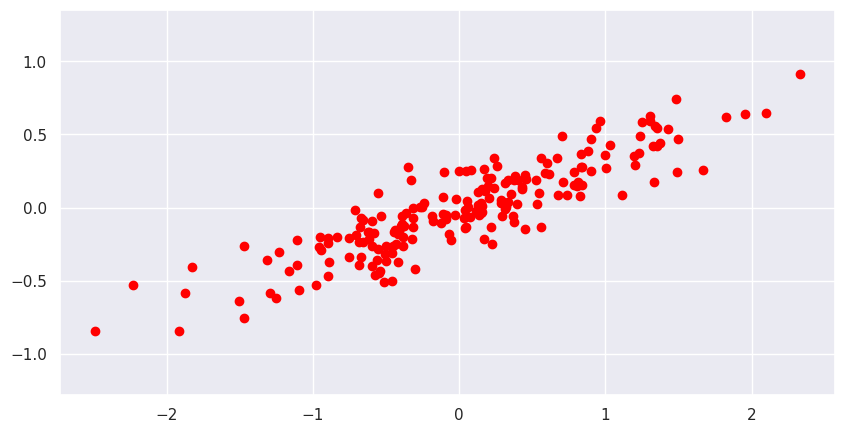

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme()

rst = np.random.RandomState(1)
plt.figure(figsize=(10,5))
X = np.dot(rst.rand(2, 2), rst.randn(2, 200)).T
plt.scatter(X[:, 0], X[:, 1], color="red")
plt.axis('equal')

Алгоритм PCA реализован в библиотеке `sklearn` в модуле `decomposition`.

В качестве аргумента PCA ожидает `n_components` - число компонент, которые мы хотим оставить, то есть размерность пространства, в которое мы переходим.

PCA - это алгоритм преобразования данных, поэтому для его использования можно воспользоваться стандартным синтаксисом `sklearn` для `transformers`, то есть вызывать функции `.fit()` и .`transform()`

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

PCA(n_components=2)

Посмотрим, как выглядят главные компоненты, обратившись к следующим атрибутам PCA:

`components` - векторы, отвечающие новой системе координат

`explained_variance` - длины векторов, соответствующие дисперсии выборки вдоль данного направления

In [ ]:
print(pca.components_)
print(pca.explained_variance_)

[[ 0.94446029  0.32862557]
 [-0.32862557  0.94446029]]
[0.7625315 0.0184779]


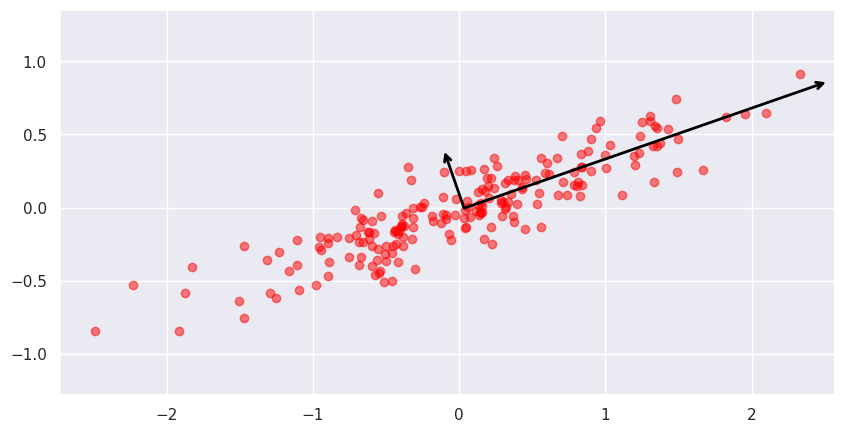

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->',
                    linewidth=2,
                    shrinkA=0,
                    shrinkB=0,
                    color='black')
    ax.annotate('', v1, v0, arrowprops=arrowprops)


plt.figure(figsize=(10,5))
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, color="red")
for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length)
    draw_vector(pca.mean_, pca.mean_ + v)
plt.axis('equal');

# Построение рекомендательных систем с помощью SVD-разложения

In [ ]:
# Пример матрицы оценок пользователей (строки — пользователи, столбцы — фильмы)
# 0 означает, что пользователь ещё не оценивал фильм
ratings = np.array([
    [5, 3, 0, 1],
    [4, 0, 0, 1],
    [1, 1, 0, 5],
    [1, 0, 0, 4],
    [0, 1, 5, 4]
])

# Выполняем SVD-разложение
U, S, Vt = np.linalg.svd(ratings)

# Преобразуем вектор S в диагональную матрицу
S_diag = np.diag(S)

# Восстанавливаем приближенную матрицу оценок, оставляя только первые k сингулярных значений
k = 2
ratings_approx = U[:, :k] @ S_diag[:k, :k] @ Vt[:k, :]

print("Исходная матрица оценок:")
print(ratings)
print("\nПриближенная матрица после SVD:")
print(np.round(ratings_approx, 2))


Исходная матрица оценок:
[[5 3 0 1]
 [4 0 0 1]
 [1 1 0 5]
 [1 0 0 4]
 [0 1 5 4]]

Приближенная матрица после SVD:
[[ 5.13  1.91 -0.72  1.56]
 [ 3.43  1.28 -0.46  1.09]
 [ 1.55  1.04  1.79  3.97]
 [ 1.18  0.8   1.4   3.09]
 [-0.45  0.54  3.1   5.15]]
